In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import logging

import matplotlib.pyplot as plt
import yaml
from datetime import datetime
import json
import h5py

# import run_tardis now. will be replaced by a more workflow style pattern latter
from tardis import run_tardis
from tardis.io.configuration.config_reader import Configuration
from tardis.util.base import atomic_number2element_symbol, int_to_roman
from tardis.visualization import SDECPlotter
from astropy import units as u, constants as cons
#matplotlib.use("Agg")


%config InlineBackend.figure_format = "retina"
logger = logging.getLogger(__name__)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True,   # important in notebooks
)


Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

Initializing tabulator and plotly panel extensions for widgets to work


In [2]:
import tardis
version = tardis.__version__
logger.info(f"The paper used TARDIS version {version}")

2026-06-20 18:06:34,715 - INFO - The paper used TARDIS version 2025.8.17


In [3]:
config_file = 'tardis_uniform_base_normal_Ia_Ni56_x0.1.yml'
model_name = 'tardis_uniform_base_normal_Ia_Ni56_x0.1'

In [4]:
def lsun_to_luminosity(model_luminosity_log_lsun):
    from astropy.constants import L_sun
    
    return 10**model_luminosity_log_lsun * L_sun.to(u.erg / u.s)

def luminosity_to_lsun(supernova_luminosity):
    from astropy.constants import L_sun

    return np.log10(supernova_luminosity / L_sun.to(u.erg / u.s).value)


class RunTardisSim:

    def __init__(self, config_file):

        self.conf = Configuration.from_yaml(config_file)
        self.conf.plasma.line_interaction_type = "macroatom"
        self.conf.model.abundances.model_isotope_time_0 = "0.0 s"

    
    def run_tardis_simulation(self):

        '''
        Function to run tardis
        '''
        logging.info("Running TARDIS simulation")
        self.sim = run_tardis(self.conf, virtual_packet_logging=True, show_convergence_plots=True)
        return self.sim


    def run_spectrum_solver(self):

        if not hasattr(self, "sim"):
            raise RuntimeError("Run a tardis simulation first")

        logging.info("Running spectrum solver")

        ss = self.sim.spectrum_solver

        self.spectrum = ss.spectrum_real_packets
        self.spectrum_virtual = ss.spectrum_virtual_packets
        self.spectrum_integrated = ss.spectrum_integrated

        return self.spectrum_integrated


    def get_spectrum(self):

        if not hasattr(self, "spectrum_integrated"):
            raise RuntimeError("Run run_spectrum_solver() first")

        self.wavelength = self.spectrum_integrated.wavelength
        self.luminosity = self.spectrum_integrated.luminosity_density_lambda

        return pd.DataFrame({'wavelength': self.wavelength, 
                             'luminosity': self.luminosity})



class LineInteractionDiagnosis:

    def __init__(self, sim):
        self.sim = sim

        # Line interaction masks

        self.line_interaction_mask = (
            sim.transport.transport_state.last_interaction_type == 2
        )

        # Frequencies

        self.freq_before_interaction = (
            sim.transport.transport_state.last_interaction_in_nu[self.line_interaction_mask] * u.Hz
        )

        self.freq_after_interaction = (
            sim.transport.transport_state.output_nu[self.line_interaction_mask]
        )

        # Wavelengths

        self.wavelength_before_interaction = (cons.c / self.freq_before_interaction).to(u.AA)
        self.wavelength_after_interaction = (cons.c / self.freq_after_interaction).to(u.AA)


        # Last interaction ids

        self.line_in_ids = sim.transport.transport_state.last_line_interaction_in_id[self.line_interaction_mask]
        self.line_out_ids = sim.transport.transport_state.last_line_interaction_out_id[self.line_interaction_mask]


        # linelist

        self.line_list = sim.plasma.atomic_data.lines.reset_index()





    def plot_line_interaction(self, savefig=False):

        self.reverse_fluorescence_mask = (
        self.wavelength_after_interaction < self.wavelength_before_interaction
        )

        n_reverse = self.reverse_fluorescence_mask.sum()

        logger.info(f"Number of packets suffering reverse fluorescence: {n_reverse}")


        fig, ax  = plt.subplots(1, figsize=(6, 6))

        ax.plot(
            self.wavelength_before_interaction[~self.reverse_fluorescence_mask],
            self.wavelength_after_interaction[~self.reverse_fluorescence_mask], 
            marker='o',
            color='red',
            ls='', 
            markersize=1, 
            alpha=0.4,
            )

        ax.plot(
            self.wavelength_before_interaction[self.reverse_fluorescence_mask],
            self.wavelength_after_interaction[self.reverse_fluorescence_mask],
            marker='x',
            color='green',
            ls='',
            markersize=1,
            alpha=0.4,
            )

        ax.plot(
            self.wavelength_before_interaction,
            self.wavelength_before_interaction,
            color='black',
            ls='--',
            alpha=0.5,
            zorder=5,
            label='No change in wavelength'
            )
        
        ax.axvspan(2300, 2800, alpha=0.3)
        ax.axvspan(3200, 3600, alpha=0.3)
        ax.axvspan(1300, 1800, alpha=0.3)

        ax.axhspan(2300, 2800, alpha=0.3)
        ax.axhspan(3200, 3600, alpha=0.3)
        ax.axhspan(1300, 1800, alpha=0.3)

        ax.set_xlabel(r"Wavelength before interaction ($\AA$)")
        ax.set_ylabel(r"Wavelength after interaction ($\AA$)")
    

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(1e3, 1e4)
        ax.set_ylim(1e3, 1e4)

        return fig, ax



    def plot_line_interaction_to_ion(self):


        self.line_in = self.line_list.loc[self.line_in_ids]
        self.line_out = self.line_list.loc[self.line_out_ids]


        self.line_in['ion_name'] = [
                f"{atomic_number2element_symbol(int(line['atomic_number']))} {int_to_roman(int(line['ion_number']))}"
                for _, line in self.line_in.iterrows()
            ]

        self.line_out['ion_name'] = [
                f"{atomic_number2element_symbol(int(line['atomic_number']))} {int_to_roman(int(line['ion_number']))}"
                for _, line in self.line_out.iterrows()
            ]



        fig, ax = plt.subplots(1, figsize=(10, 6))
        colors = plt.cm.tab20(np.linspace(0, 1, len(self.line_in["ion_name"].unique())))

        for ion_name, color in zip(self.line_in["ion_name"].unique(), colors):
            #print (ion_name, color)
            if ion_name.endswith(' '):
                pass
            else:
                mask = self.line_in["ion_name"] == ion_name

            ax.plot(
                self.wavelength_before_interaction[mask],
                self.wavelength_after_interaction[mask],
                "o",
                markersize=1,
                alpha=0.7,
                label=ion_name,
                zorder=1,
                color=color
            )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(8e2, 1e4)
        ax.axvspan(2300, 2800, alpha=0.3)
        ax.axvspan(3200, 3600, alpha=0.3)
        ax.axvspan(1300, 1800, alpha=0.3)

        ax.axhspan(2300, 2800, alpha=0.3)
        ax.axhspan(3200, 3600, alpha=0.3)
        ax.axhspan(1300, 1800, alpha=0.3)
        ax.legend(markerscale=5, ncols=4, bbox_to_anchor=(0.45, 1.35), loc='upper center')


        return fig, ax


    def sdec_plotter(self, species_list=['Si II', 'Ca II', 'Fe II', 'Fe III'], wave_lower=1000, wave_upper=10000):

        # generate the plotter object

        plotter = SDECPlotter.from_simulation(self.sim)


        fig, ax = plt.subplots(1, figsize=(10, 7))
        plotter.generate_plot_mpl(species_list = species_list,
                          packet_wvl_range=[wave_lower, wave_upper] * u.AA,
                          ax=ax)
        return fig, ax


    def get_binned_tau_sobolev(self, species=(28, 1)):

        # selecting the ion we want

        self.ion = self.sim.plasma.tau_sobolevs.loc[species].sort_index()
        # Summing tau sobolev values over shells to get a single tau sobolev
        self.tau_sobolevs_sum_over_shell = self.ion.sum(axis=1).to_frame('tau_sobolev')
        # atomic linelist from the data
        self.atomic_linelist = self.line_list
        # converting wavelength in cm to wavelength in A
        self.atomic_linelist['wavelength_A'] = self.atomic_linelist['wavelength_cm'] * 1e8

        self.tau_sobolevs_wavelength = self.tau_sobolevs_sum_over_shell.merge(self.atomic_linelist, 
                                                                         how="inner", on=['level_number_lower', 'level_number_upper']).reset_index()
        
        
        bin_width = 20.0

        wmin = self.tau_sobolevs_wavelength['wavelength_A'].min()
        wmax = self.tau_sobolevs_wavelength['wavelength_A'].max()

        self.bins = np.arange(wmin, wmax + bin_width, bin_width)

        self.tau_sobolevs_wavelength['lambda_bin'] = np.digitize(self.tau_sobolevs_wavelength['wavelength_A'], self.bins)

        self.tau_sobolevs_wavelength['lambda_center'] = 0.5 * (self.bins[self.tau_sobolevs_wavelength['lambda_bin']-1] + 
                                                               self.bins[self.tau_sobolevs_wavelength['lambda_bin']])
        
        self.binned_tau_sobolev = self.tau_sobolevs_wavelength.groupby('lambda_bin')['tau_sobolev'].sum().reset_index()

        self.binned_tau_sobolev = self.tau_sobolevs_wavelength.groupby('lambda_center')['tau_sobolev'].sum().reset_index()

        return self.binned_tau_sobolev

        
        
class SimulationLogger:

    '''
    This class handles basic simulation info for diagnostics.
    '''

    def __init__(self, sim):
        self.sim = sim

    def simulation_info(self):

        v_inner = sim.simulation_state.geometry.v_inner.to(u.km/u.s).value
        v_outer = sim.simulation_state.geometry.v_outer.to(u.km/u.s).value
        t_inner = sim.simulation_state.t_inner.value
        w = sim.simulation_state.dilution_factor
        trad = sim.simulation_state.t_radiative.value
        ne = sim.plasma.electron_densities.values
        mass = (sim.simulation_state.density * sim.simulation_state.volume).to(u.Msun).value
        status = sim.converged
        executed_iterations = sim.iterations_executed

        simulations_log = {
            "status": status,
            "iterations_exec": executed_iterations,
            "v_inner": v_inner,
            "v_outer": v_outer,
            "t_inner": t_inner,
            "dilution_factor": w,
            "radiative_temperature": trad,
            "electron_number_density": ne,
            "shell_mass": mass
        }

        return simulations_log


    def composition_info(self):

        mass_fractions = self.sim.simulation_state.composition.nuclide_mass_fraction

        return mass_fractions



class TardisModelSaver:

    def __init__(self, model_name, base_dir="results"):

        self.model_name = model_name
        self.base_path = Path(base_dir) / model_name

        self.plot_path = self.base_path / "plots"

        self.base_path.mkdir(parents=True, exist_ok=True)
        self.plot_path.mkdir(parents=True, exist_ok=True)

        self.meta = {}

    def save_config(self, config):

        config_path = self.base_path / "config.yml"
        with open (config_path, "w") as f:
            yaml.dump(config, f, default_flow_style=False)

        self.meta['config_saved'] = str(config_path)

    def save_spectrum(self, spectrum_df):


        path = self.base_path / "spectrum.csv"
        spectrum_df.to_csv(path, index=False)

        self.meta['spectrum_saved'] = str(path)

    def save_plot(self, fig, name):

        path = self.plot_path / f"{name}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        self.meta.setdefault("plots", []).append(str(path))

    
    def save_simulation_info(self, simulation_log):

        path = self.base_path / "simulation.h5"

        with h5py.File(path, "w") as f:
            for key, value in simulation_log.items():
                f[key] = value

        self.meta["simulation_log"] = str(path)


    def save_binned_tau_sobolev(self, binned_tau_sobolev_df, species):

        path = self.base_path / f"binned_tau_{species}.csv"
        binned_tau_sobolev_df.to_csv(path, sep=' ', index=True)

        self.meta['binned_tau_sobolevs_saved'] = str(path)

    
    def save_mass_fractions(self, mass_fraction_df):

        path = self.base_path / "mass_fractions.csv"
        mass_fraction_df.to_csv(path, sep=' ', index=True)

        self.meta['mass_fraction_saved'] = str(path)
        

    def finalize(self):
        self.meta["time_stamp"] = datetime.now().isoformat()

        path = self.base_path / "meta.json"

        with open(path, "w") as f:
            json.dump(self.meta, f, indent=4)

    

In [5]:
runner = RunTardisSim(config_file)
sim = runner.run_tardis_simulation()

2026-06-20 18:06:34,761 - INFO - Running TARDIS simulation


Auto-detected VSCode environment
Initializing panel with ipywidgets comms for VSCode


Auto-detected VSCode environment
Initializing panel with ipywidgets comms for VSCode


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


TqdmHBox(children=(HTML(value='Iterations:', layout=Layout(width='6%')), FloatProgress(value=0.0, layout=Layou…

TqdmHBox(children=(HTML(value='Packets:\u2007\u2007\u2007', layout=Layout(width='6%')), FloatProgress(value=0.…

    'data': [{'type': 'scatter', 'uid': '9c8033b4-abe2-4883-b4d6-e53ee385acb7', …

Embedding the final state for Jupyter environments


In [6]:
spectrum = runner.run_spectrum_solver()

INFO:root:Running spectrum solver


In [7]:
spectrum_df = runner.get_spectrum()

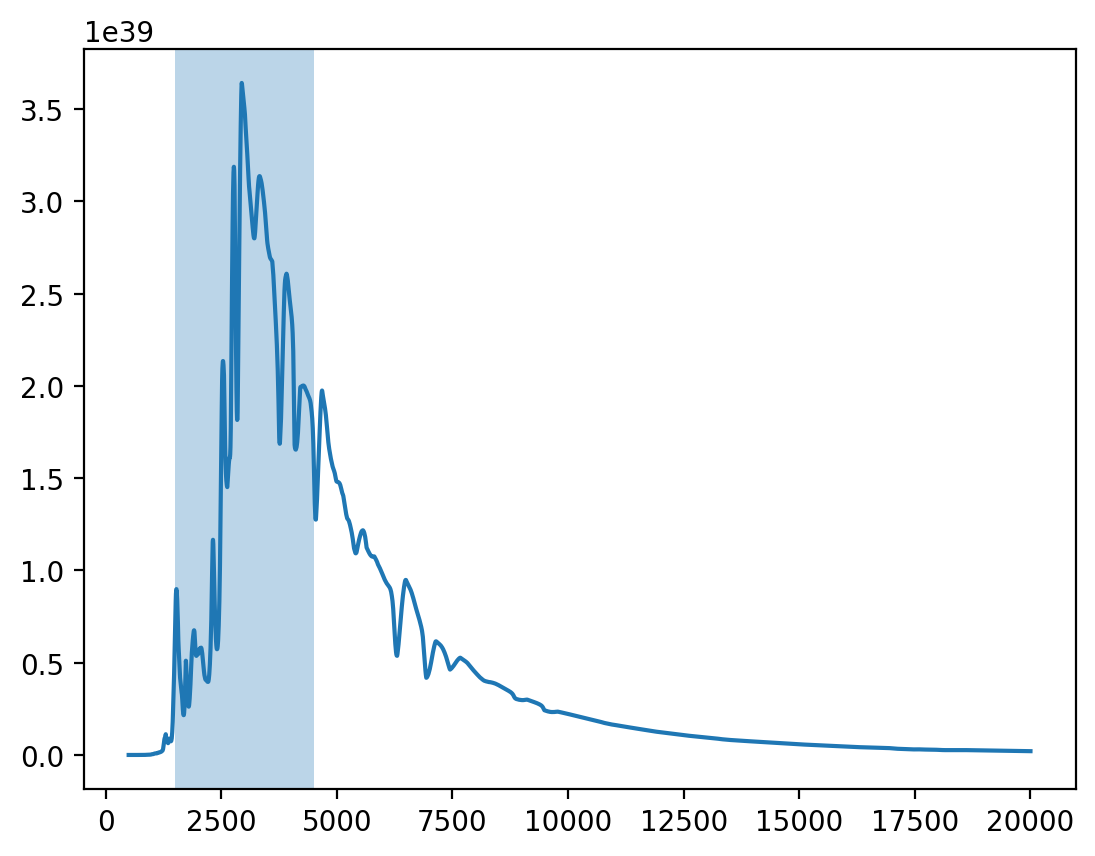

In [17]:
plt.plot(spectrum_df['wavelength'], spectrum_df['luminosity'])
plt.axvspan(1500, 4500, alpha=0.3)
#plt.xlim(1500, 4000)

In [9]:
line_interaction_diagnosis = LineInteractionDiagnosis(sim)

INFO:__main__:Number of packets suffering reverse fluorescence: 107166


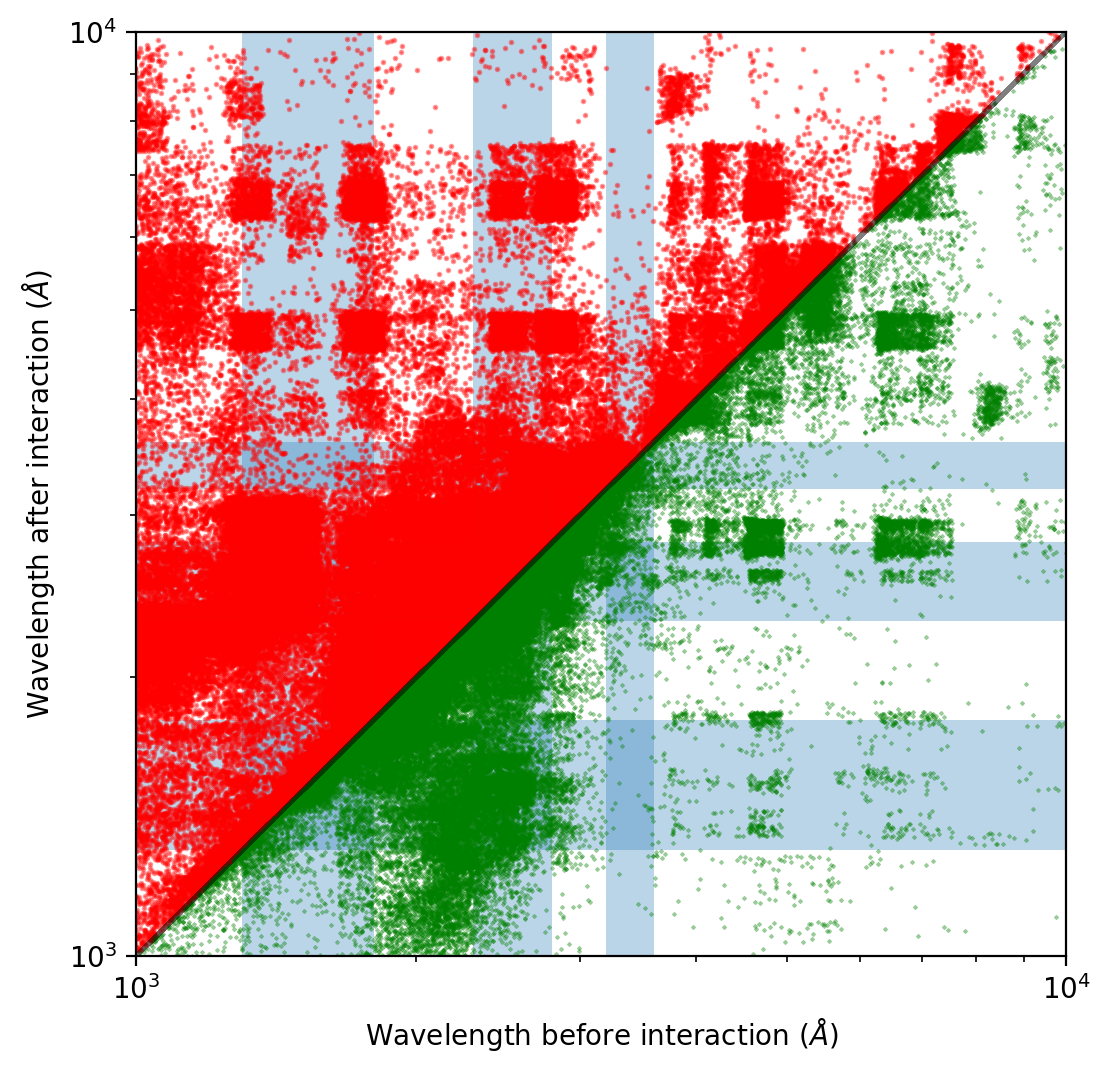

In [10]:
fig1, ax1 = line_interaction_diagnosis.plot_line_interaction()

In [ ]:
fig2, ax2 = line_interaction_diagnosis.plot_line_interaction_to_ion()

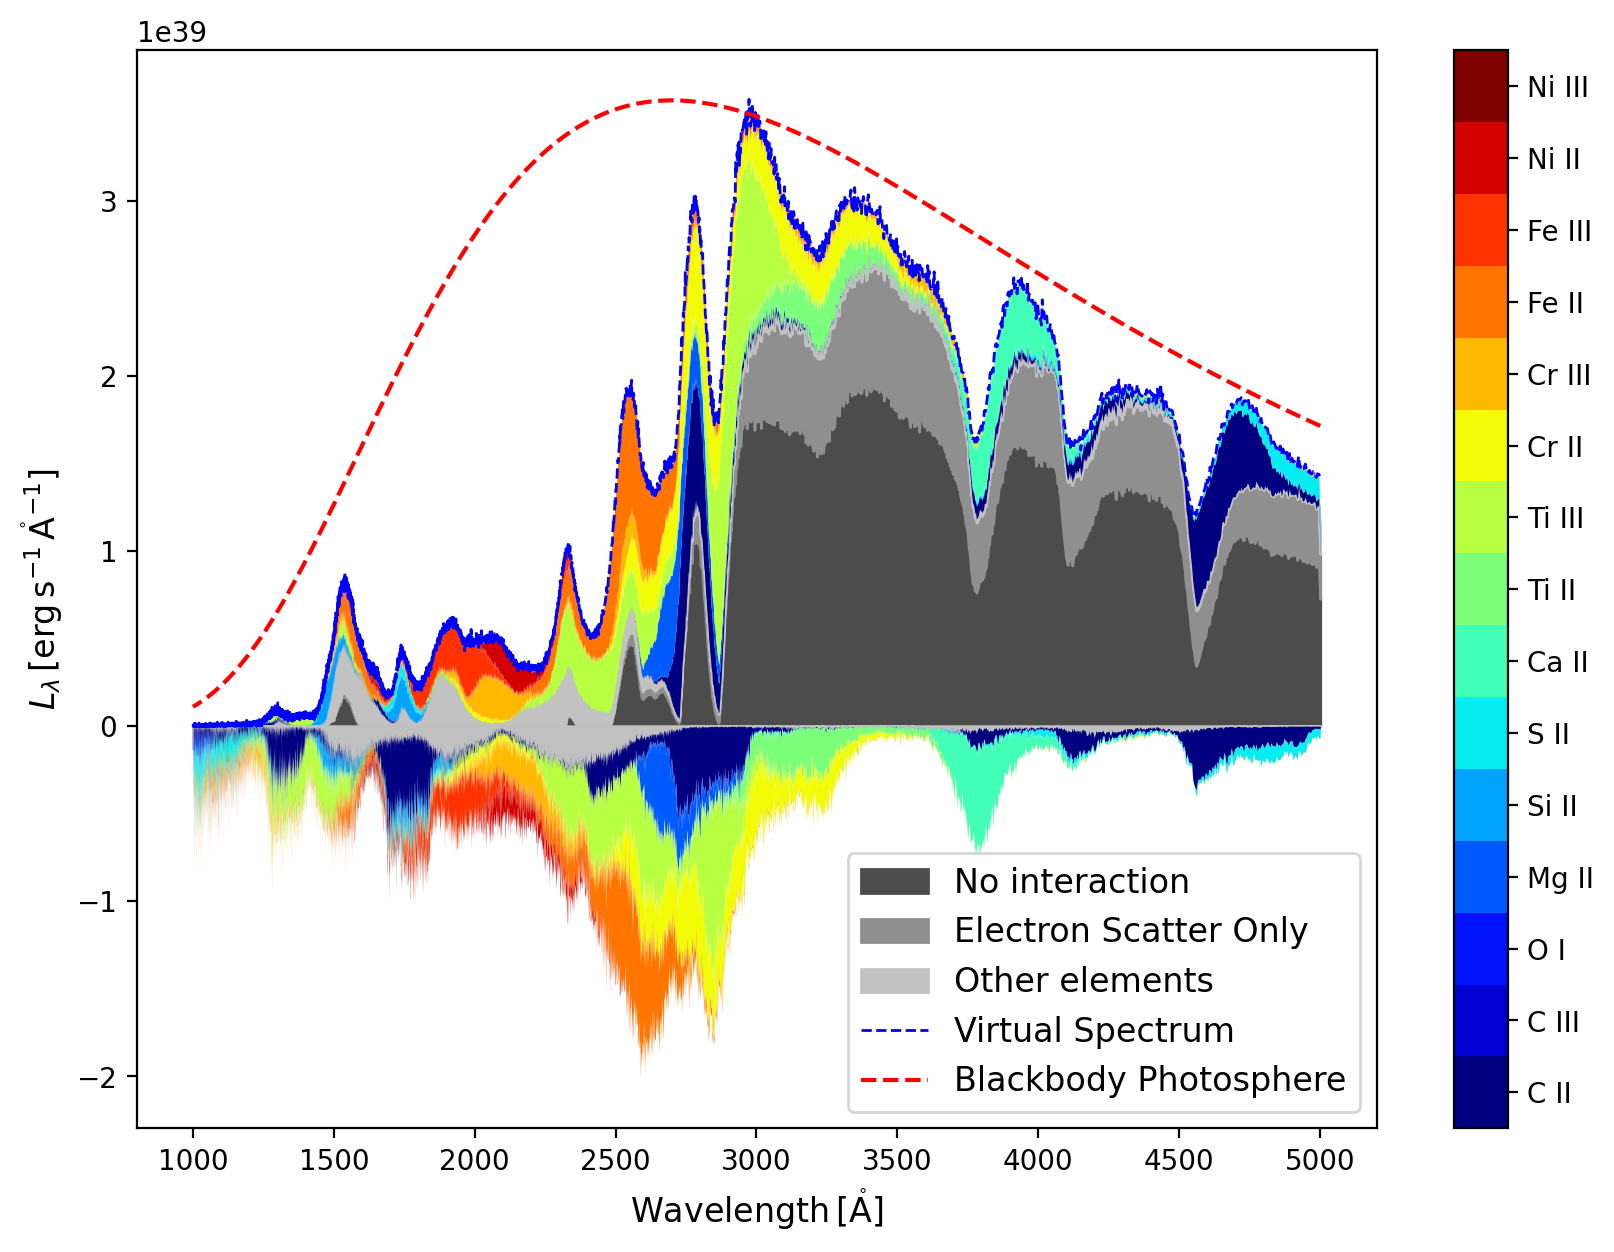

In [12]:
fig3, ax3 = line_interaction_diagnosis.sdec_plotter(species_list=['C II', 'C III', 'O I', 'Mg II', \
                                                                 'S II', 'Si II', 'Ca II', 'Fe II', 'Fe III', \
                                                                 'Ti II', 'Ti III', 'V II', 'V III', 'Cr II', 'Cr III', \
                                                                 'Ni II', 'Ni III'],
                                                                 wave_lower=1000, wave_upper=5000)
#ax3.axvspan(2300, 2800, alpha=0.3)
#ax3.axvspan(3200, 3600, alpha=0.3)
#ax3.axvspan(1300, 1800, alpha=0.3)
#ax3.set_ylim(0, 0.6e39)





In [ ]:
simlogger = SimulationLogger(sim)


In [ ]:
simulations_log = simlogger.simulation_info()

In [ ]:
composition_df = simlogger.composition_info()

In [ ]:
saver = TardisModelSaver(model_name)

In [ ]:
saver.save_config(runner.conf)

In [ ]:
binned_tau_sobolev_ni_ii = line_interaction_diagnosis.get_binned_tau_sobolev(species=(28, 1))
binned_tau_sobolev_ni_iii = line_interaction_diagnosis.get_binned_tau_sobolev(species=(28, 2))

binned_tau_sobolev_fe_ii = line_interaction_diagnosis.get_binned_tau_sobolev(species=(26, 1))
binned_tau_sobolev_fe_iii = line_interaction_diagnosis.get_binned_tau_sobolev(species=(26, 2))

binned_tau_sobolev_co_ii = line_interaction_diagnosis.get_binned_tau_sobolev(species=(27, 1))
binned_tau_sobolev_co_iii = line_interaction_diagnosis.get_binned_tau_sobolev(species=(27, 2))

In [ ]:
saver.save_binned_tau_sobolev(binned_tau_sobolev_ni_ii, species='Ni_II')
saver.save_binned_tau_sobolev(binned_tau_sobolev_ni_iii, species='Ni_III')

saver.save_binned_tau_sobolev(binned_tau_sobolev_fe_ii, species='Fe_II')
saver.save_binned_tau_sobolev(binned_tau_sobolev_fe_iii, species='Fe_III')

saver.save_binned_tau_sobolev(binned_tau_sobolev_co_ii, species='Co_II')
saver.save_binned_tau_sobolev(binned_tau_sobolev_co_iii, species='Co_III')


In [ ]:
saver.save_spectrum(spectrum_df)

In [ ]:
saver.save_plot(fig1, "last_interaction")

In [ ]:
saver.save_plot(fig2, "last_interaction_ion")

In [ ]:
saver.save_plot(fig3, "sdec")

In [ ]:
saver.save_simulation_info(simulations_log)

In [ ]:
saver.save_mass_fractions(composition_df)

In [ ]:
saver.finalize()